In [1]:
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0 # (48000, 28, 28) 크기 train_input -> (48000, 28, 28, 1)
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [2]:
# 합성곱 신경망 만들기
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28, 1))) # 입력 -> (28, 28, 1) 그레이스케일 이미지

# 합성곱 층 & 풀링 층 추가 1: (28, 28, 32) -> (14, 14, 32)
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')) # 필터 32개, 커널 크기 (3, 3), 렐루 활성화 함수, Same Padding
model.add(keras.layers.MaxPool2D(2)) # (2, 2) 최대 풀링

# 합성곱 층 & 풀링 층 추가 2: (14, 14, 32) -> (7, 7, 64)
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')) # 필터 64개 사용
model.add(keras.layers.MaxPooling2D(2))

# 3차원 특성 맵 일렬로 펼치고 밀집 은닉층에 전달하기
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu')) # 뉴런 100개
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax')) # 클래스 10개 분류하는 다중 분류 -> 소프트맥스 활성화 함수

In [3]:
# 모델 구조 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

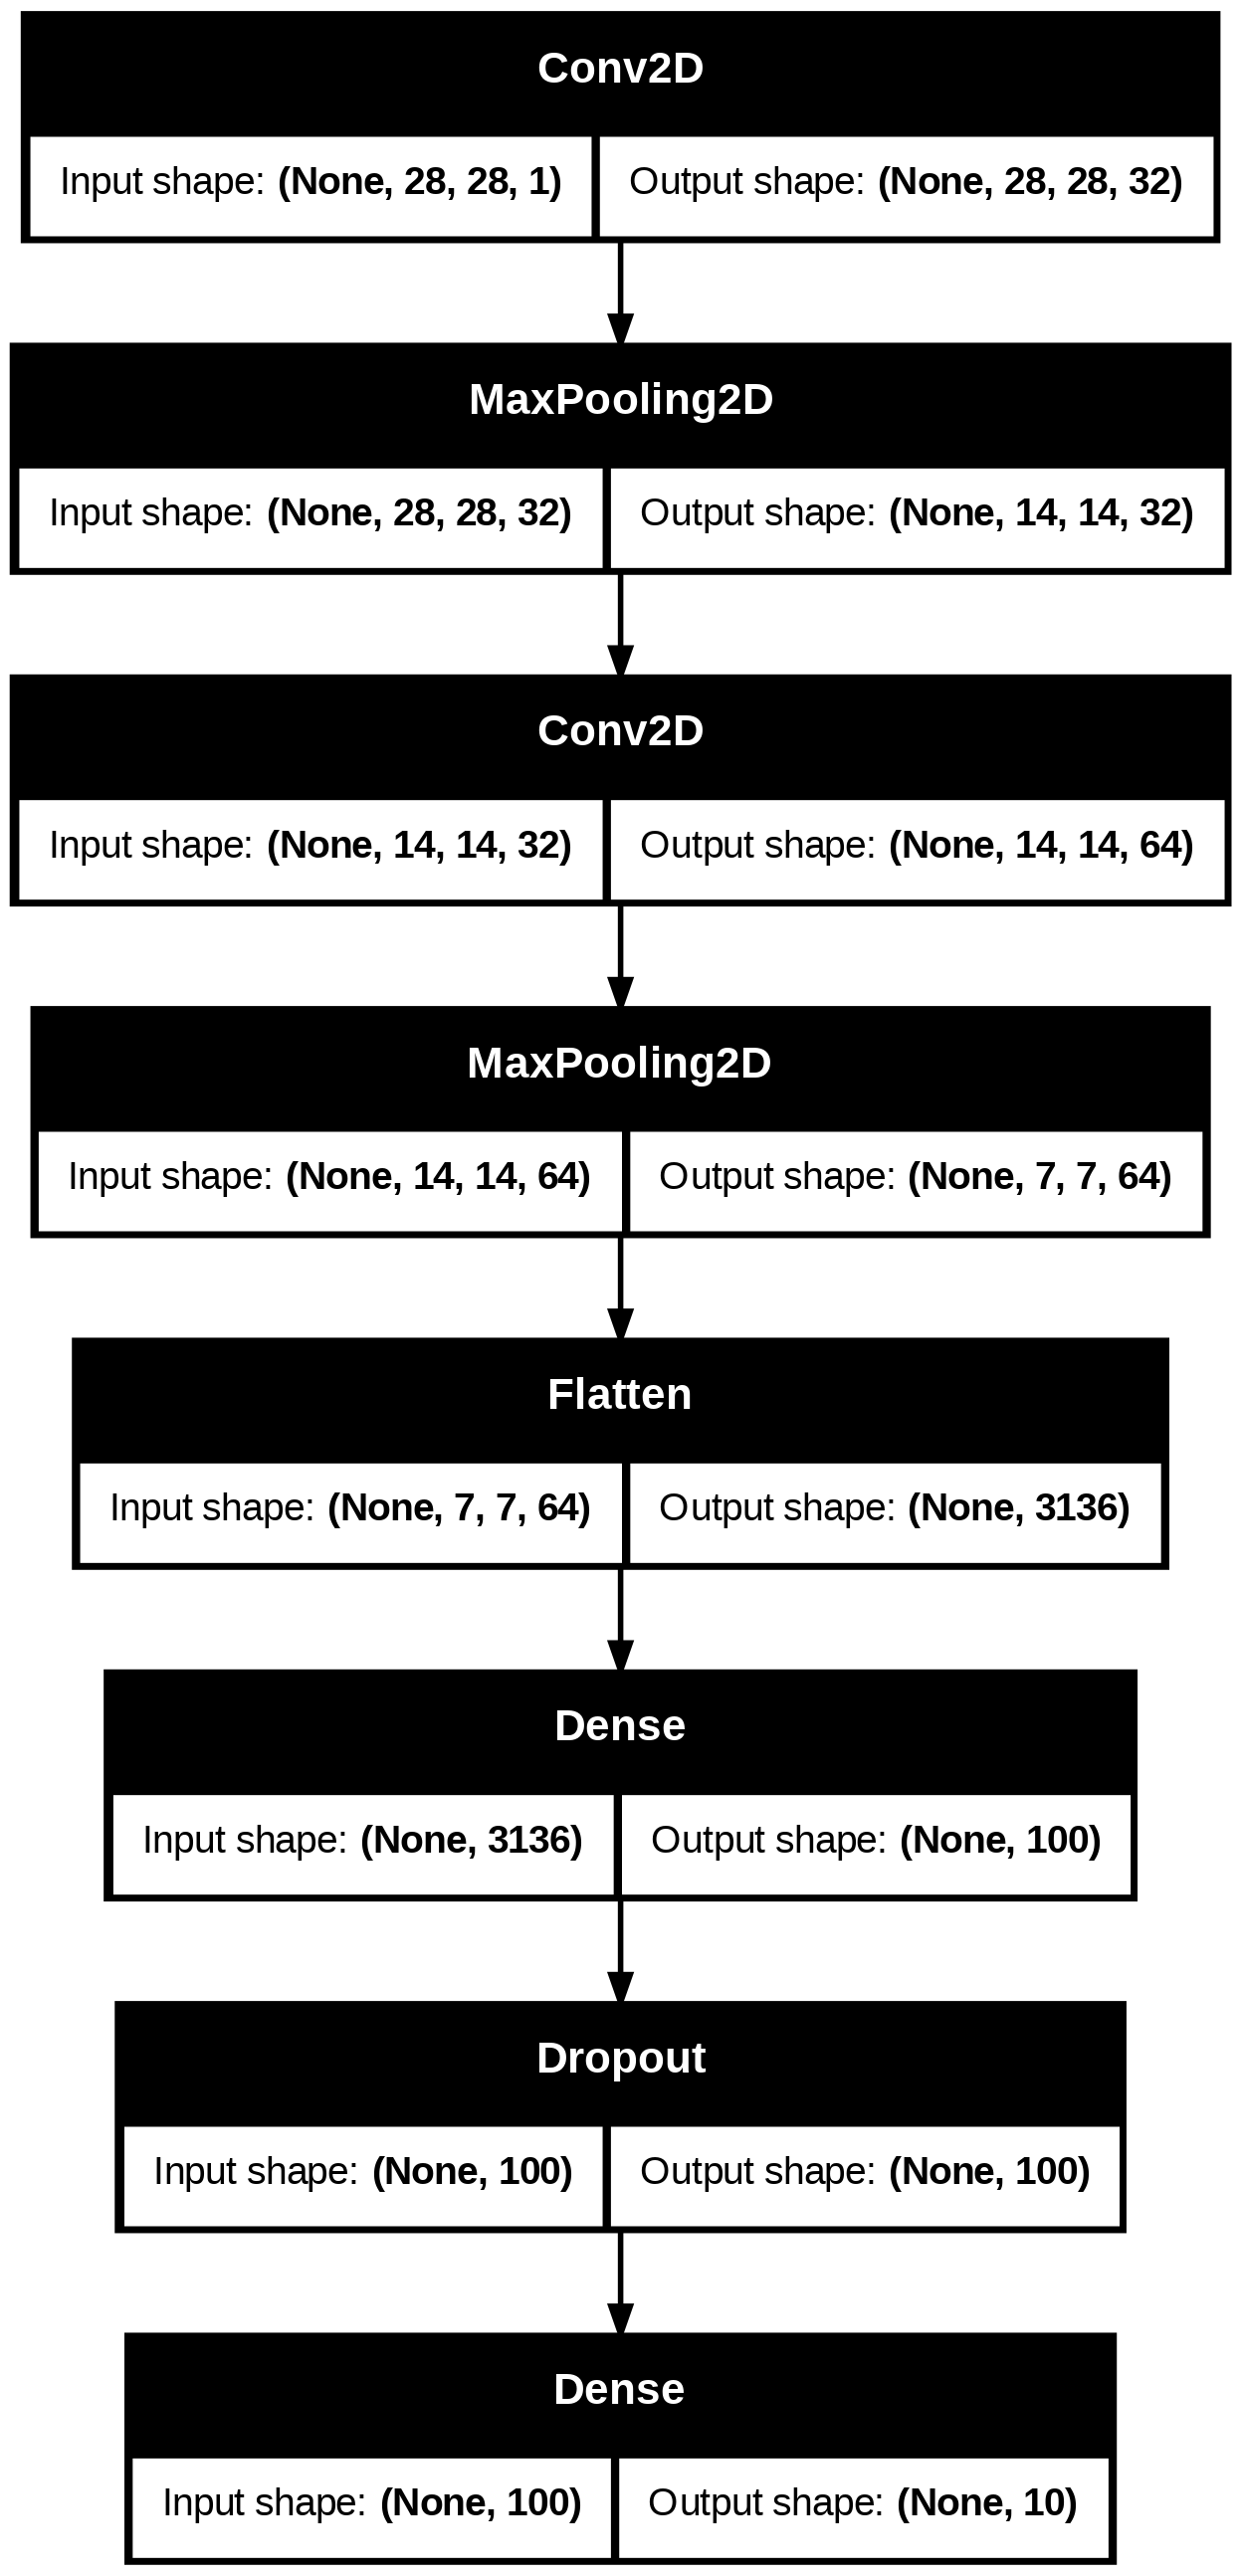

In [4]:
# 모델 구조 시각화
keras.utils.plot_model(model, show_shapes=True)

---

### 모델 컴파일 & 훈련

In [5]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 137s 89ms/step - accuracy: 0.7399 - loss: 0.7324 - val_accuracy: 0.8775 - val_loss: 0.3360
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 125s 78ms/step - accuracy: 0.8679 - loss: 0.3617 - val_accuracy: 0.8951 - val_loss: 0.2815
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 124s 66ms/step - accuracy: 0.8904 - loss: 0.3063 - val_accuracy: 0.8995 - val_loss: 0.2681
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 176s 89ms/step - accuracy: 0.9040 - loss: 0.2703 - val_accuracy: 0.9081 - val_loss: 0.2546
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 126s 84ms/step - accuracy: 0.9128 - loss: 0.2406 - val_accuracy: 0.9159 - val_loss: 0.2314
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 126s 84ms/step - accuracy: 0.9181 - loss: 0.2219 - val_accuracy: 0.9182 - val_loss: 0.2246
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.9247 - loss: 0.2065 - val_accuracy: 0.9143 - val_loss: 0.2370
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.

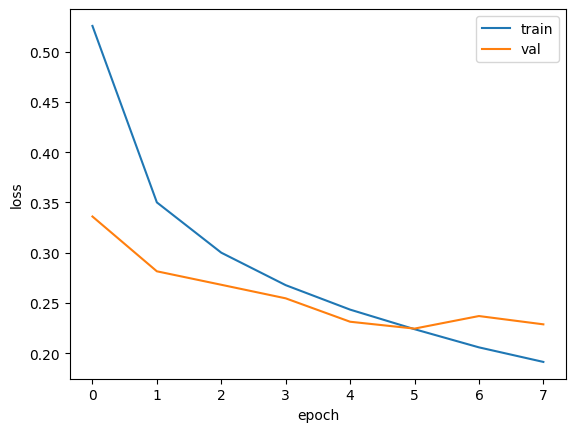

In [6]:
# 손실 그래프로 조기 종료 확인
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()